In [1]:
import torch
import torch.nn as nn
import numpy as np
import pandas as pd
import os
from torch.utils.data import DataLoader, Dataset
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score, mean_absolute_percentage_error
import matplotlib.pyplot as plt
from tqdm import tqdm
import xgboost as xgb

In [179]:
#get blocks
dataset_path = './dataset/'
items = os.listdir(dataset_path)
blocks =[item for item in items if os.path.isdir(os.path.join(dataset_path, item))]

#blocks = ['sasc_top', 'dynamic_node_top_wrap','risc16f84_clk2x','picosoc','jpeg_encoder']
#blocks = ['simple_spi_top','pci_bridge32','dft_top','aes128_core','mc_top']
#blocks = ['aes_cipher_top','wb_conmax_top','FIR_filter','RsEncodeTop','mips_core']
#blocks = ['sdram','Sha3BlackBox','des3','Network','RocketTile']
#blocks = ['vga_enh_top','RsDecodeTop','spi_top','psram_core','usb_phy']
#blocks = ['aes_core','plic_core','mrisc_top','rs_encode','Top_PipelinedCipher']
#blocks = ['pcm_slv_top','wb_dma_top','ac97_top','fpu', 'sha256']

df_blocks_list = []
        
for block in blocks:

    #get net_feat.csv (feate store and labels)
    df = pd.read_csv(f"./{dataset_path}/{block}/net_feat.csv", sep=';')

    #drop all nets with zero capacitence
    df = df[df['cap'] != 0]
    df = df[df['pin_cap'] != 0]

    #drop all Nan rows
    df = df.dropna()
    
    #print(f'{block} {len(df['net'])}')

    #drop net name clomun
    df = df.drop(columns=['net'], axis=1)

    #append df to common df
    df_blocks_list.append(df)

#create common df
df = pd.concat(df_blocks_list, ignore_index=True)

#transfer capacintece from pF to fF
df['cap'] = df['cap'] * 1000
df['pin_cap'] = df['pin_cap'] * 1000
df['wireload_fan_cap'] = df['wireload_fan_cap'] * 1000
df['wireload_hpwl_cap'] = df['wireload_hpwl_cap'] * 1000

#add block area feature
df['block_area'] = df['block_width'] * df['block_height']

#add area feature
df['gcell_area'] = (df['urx'] - df['llx']) * (df['ury'] - df['lly'])

#add aspect ration feat
df['gcell_ar'] = (df['urx'] - df['llx']) / (df['ury'] - df['lly'])

#df['abs_x']= (((df['urx'] - df['llx']) / 2) + df['llx']) / df['block_width']
#df['abs_y']= (((df['ury'] - df['lly']) / 2) + df['lly']) / df['block_height']

df['dist_to_right'] = ((df['block_width'] - ((df['urx'] - df['llx']) / 2) + df['llx'])) / df['block_width']
df['dist_to_left'] = (((df['urx'] - df['llx']) / 2) + df['llx']) / df['block_width']

df['dist_to_top'] = (df['block_height'] - (((df['ury'] - df['lly']) / 2) + df['lly'])) / df['block_height']
df['dist_to_bottom'] =(( ((df['ury'] - df['lly']) / 2) + df['lly']))

#ration wire cap / pin cap
#df ['wire_to_pin_cap_ratio'] = df['cap'] / df['pin_cap'] 

#drop metal segs
df = df.drop(columns=['m2_segs', 'm3_segs', 'm4_segs', 'm5_segs', 'm6_segs', 'm7_segs'])

#drop all labels except cap
#df = df.drop(columns=['length', 'vias', 'segs'])

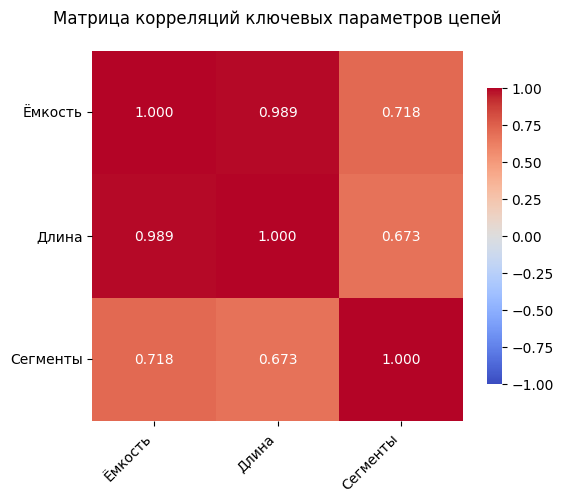

Матрица корреляций Пирсона:
          cap  length   segs
cap     1.000   0.989  0.718
length  0.989   1.000  0.673
segs    0.718   0.673  1.000


In [73]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Настройки для визуализации в статье
plt.style.use('default')  # Чистый стиль для публикации
sns.set_palette("viridis")

# Выбираем только нужные колонки
features_to_plot = ['cap', 'length', 'segs']
df_subset = df[features_to_plot]

# Считаем матрицу корреляций
corr_matrix = df_subset.corr(method='pearson')  # Можно использовать 'spearman' для нелинейных зависимостей

# Создаем фигуру с подходящим размером для статьи
fig, ax = plt.subplots(figsize=(6, 5))

# Рисуем heatmap с аннотациями
heatmap = sns.heatmap(corr_matrix, 
                      annot=True,           # Показать числа в ячейках
                      fmt='.3f',           # Формат чисел: 3 знака после запятой
                      cmap='coolwarm',     # Цветовая схема: синий-белый-красный
                      center=0,            # Центр цветовой шкалы на 0
                      vmin=-1, vmax=1,     # Диапазон коэффициентов корреляции
                      square=True,         # Квадратные ячейки
                      cbar_kws={'shrink': 0.8},  # Настройка цветовой шкалы
                      ax=ax)

# Настраиваем labels для читаемости в статье
ax.set_xticklabels(['Ёмкость', 'Длина', 'Сегменты'], rotation=45, ha='right')
ax.set_yticklabels(['Ёмкость', 'Длина', 'Сегменты'], rotation=0)

# Заголовок для статьи
plt.title('Матрица корреляций ключевых параметров цепей', pad=20, fontsize=12)

# Улучшаем компоновку
plt.tight_layout()

# Для сохранения в высоком качестве для статьи
plt.savefig('correlation_heatmap.png', dpi=300, bbox_inches='tight')

plt.show()

# Дополнительно: выводим численные значения для текста статьи
print("Матрица корреляций Пирсона:")
print(corr_matrix.round(3))

Целевые метрики: ['cap']
Количество других признаков: 29
Другие признаки: ['block_width', 'block_height', 'fanin', 'fanout', 'fanin_area', 'fanout_area', 'llx', 'lly', 'urx', 'ury']...

Размерность матрицы корреляций: (1, 29)

Топ-5 признаков по корреляции с ёмкостью:
length               0.989324
hpwl                 0.924080
hpwl_max             0.894981
wireload_hpwl_cap    0.869079
hpwl_mean            0.823910
Name: cap, dtype: float64


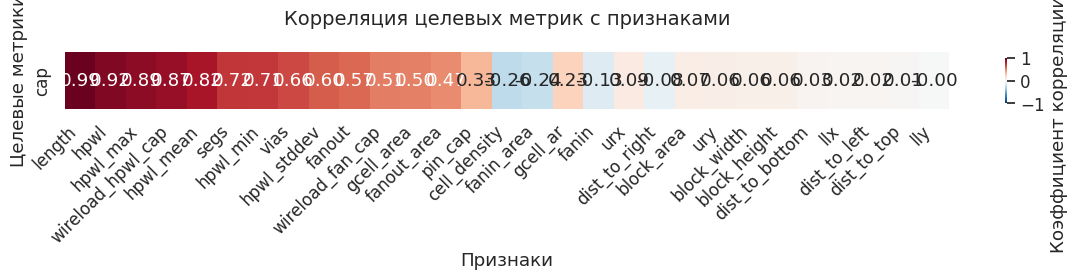

In [76]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Настройки для статьи
plt.style.use('default')
sns.set(font_scale=1.1)

# 1. Выделяем целевые метрики и все остальные признаки
#target_metrics = ['cap', 'length', 'segs']
target_metrics = ['cap']
other_features = [col for col in df.columns if col not in target_metrics]

print(f"Целевые метрики: {target_metrics}")
print(f"Количество других признаков: {len(other_features)}")
print(f"Другие признаки: {other_features[:10]}...")  # Покажем первые 10

# 2. Создаем пустую матрицу для корреляций
corr_matrix = pd.DataFrame(index=target_metrics, columns=other_features)

# 3. Заполняем матрицу корреляциями
for target in target_metrics:
    for feature in other_features:
        corr_matrix.loc[target, feature] = df[target].corr(df[feature])

# Конвертируем в float
corr_matrix = corr_matrix.astype(float)

print("\nРазмерность матрицы корреляций:", corr_matrix.shape)
print("\nТоп-5 признаков по корреляции с ёмкостью:")
print(corr_matrix.loc['cap'].abs().sort_values(ascending=False).head())

# 4. Визуализация - heatmap
fig, ax = plt.subplots(figsize=(12, 3))

# Сортируем признаки по корреляции с ёмкостью для лучшей читаемости
sorted_features = corr_matrix.loc['cap'].abs().sort_values(ascending=False).index
corr_sorted = corr_matrix[sorted_features]

heatmap = sns.heatmap(corr_sorted, 
                      annot=True,           # Числа в ячейках
                      fmt='.2f',           # 2 знака после запятой
                      cmap='RdBu_r',       # Красно-синяя палитра
                      center=0,            # Центр на 0
                      vmin=-1, vmax=1,     # Полный диапазон корреляции
                      cbar_kws={'label': 'Коэффициент корреляции Пирсона', 'shrink': 0.8},
                      ax=ax)

# Настройка подписей
ax.set_ylabel('Целевые метрики')
ax.set_xlabel('Признаки')
ax.set_title('Корреляция целевых метрик с признаками', pad=20, fontsize=14)

# Поворачиваем подписи признаков для читаемости
plt.xticks(rotation=45, ha='right')
plt.tight_layout()

plt.savefig('targets_correlation_heatmap.png', dpi=300, bbox_inches='tight')
plt.show()

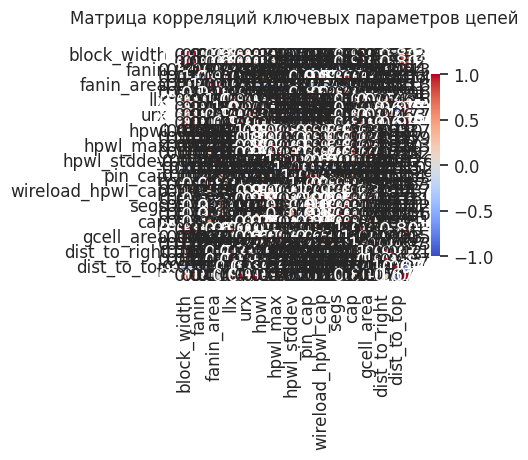

Матрица корреляций Пирсона:
     block_width  block_height  fanin  fanout  fanin_area  fanout_area    llx  \
cap        0.062         0.061 -0.126   0.572      -0.238        0.469  0.021   

       lly    urx    ury  ...  length   segs   vias  block_area  gcell_area  \
cap -0.001  0.087  0.063  ...   0.989  0.718  0.659       0.071       0.502   

     gcell_ar  dist_to_right  dist_to_left  dist_to_top  dist_to_bottom  
cap     0.233          -0.08         0.018        0.011           0.031  

[1 rows x 29 columns]


In [81]:
heatmap = sns.heatmap(df.corr(), 
                      annot=True,           # Показать числа в ячейках
                      fmt='.3f',           # Формат чисел: 3 знака после запятой
                      cmap='coolwarm',     # Цветовая схема: синий-белый-красный
                      center=0,            # Центр цветовой шкалы на 0
                      vmin=-1, vmax=1,     # Диапазон коэффициентов корреляции
                      square=True,         # Квадратные ячейки
                      cbar_kws={'shrink': 0.8}  # Настройка цветовой шкалы
 )

# Настраиваем labels для читаемости в статье
#ax.set_xticklabels(['Ёмкость', 'Длина', 'Сегменты'], rotation=45, ha='right')
#ax.set_yticklabels(['Ёмкость', 'Длина', 'Сегменты'], rotation=0)

# Заголовок для статьи
plt.title('Матрица корреляций ключевых параметров цепей', pad=20, fontsize=12)

# Улучшаем компоновку
plt.tight_layout()

# Для сохранения в высоком качестве для статьи
plt.savefig('correlation_heatmap.png', dpi=300, bbox_inches='tight')

plt.show()

# Дополнительно: выводим численные значения для текста статьи
print("Матрица корреляций Пирсона:")
print(corr_matrix.round(3))

In [86]:
df.corr() > 0.1

,block_width,block_height,fanin,fanout,fanin_area,fanout_area,llx,lly,urx,ury,...,segs,vias,cap,block_area,gcell_area,gcell_ar,dist_to_right,dist_to_left,dist_to_top,dist_to_bottom
block_width,True,True,False,False,False,False,True,True,True,True,...,False,False,False,True,False,False,True,True,False,True
block_height,True,True,False,False,False,False,True,True,True,True,...,False,False,False,True,False,False,True,True,False,True
fanin,False,False,True,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
fanout,False,False,False,True,False,True,False,False,False,False,...,True,True,True,False,False,False,False,False,False,False
fanin_area,False,False,False,False,True,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
fanout_area,False,False,False,True,False,True,False,False,False,False,...,True,True,True,False,False,False,False,False,False,False
llx,True,True,False,False,False,False,True,True,True,True,...,False,False,False,True,False,False,True,True,False,True
lly,True,True,False,False,False,False,True,True,True,True,...,False,False,False,True,False,False,False,False,False,True
urx,True,True,False,False,False,False,True,True,True,True,...,False,False,False,True,False,False,True,True,False,True
ury,True,True,False,False,False,False,True,True,True,True,...,False,False,False,True,False,False,False,False,False,True


In [87]:
# Создаем матрицу корреляций
corr = df.corr()

# Создаем маску для значений меньше 0.1 по модулю
mask = (corr.abs() < 0.1) & (corr.abs() > 0)  # Исключаем диагональ (значения 1.0)

# Применяем маску (заменяем малые значения на NaN)
corr_filtered = corr.where(corr.abs() >= 0.1)

# Стилизуем отфильтрованную матрицу
corr_filtered.style.background_gradient(cmap='Reds', vmin=-1, vmax=1)

,block_width,block_height,fanin,fanout,fanin_area,fanout_area,llx,lly,urx,ury,hpwl,hpwl_min,hpwl_max,hpwl_mean,hpwl_stddev,cell_density,pin_cap,wireload_fan_cap,wireload_hpwl_cap,length,segs,vias,cap,block_area,gcell_area,gcell_ar,dist_to_right,dist_to_left,dist_to_top,dist_to_bottom
block_width,1.000000,0.999997,nan,nan,nan,nan,0.663950,0.799763,0.668171,0.804744,nan,0.115780,nan,0.105408,nan,-0.106994,nan,nan,0.190638,nan,nan,nan,nan,0.983303,nan,nan,0.165558,0.124723,-0.201541,0.803238
block_height,0.999997,1.000000,nan,nan,nan,nan,0.663984,0.799758,0.668203,0.804736,nan,0.115763,nan,0.105385,nan,-0.107024,nan,nan,0.190618,nan,nan,nan,nan,0.983279,nan,nan,0.165604,0.124770,-0.201558,0.803231
fanin,nan,nan,1.000000,-0.271232,nan,-0.248438,nan,nan,nan,nan,nan,nan,nan,nan,-0.159915,nan,-0.247242,-0.220056,nan,-0.123840,-0.197272,-0.236651,-0.126016,nan,nan,nan,nan,nan,nan,nan
fanout,nan,nan,-0.271232,1.000000,-0.156848,0.924941,nan,nan,nan,nan,0.291969,nan,0.235967,0.126938,0.489689,nan,0.432471,0.944000,0.254751,0.535190,0.912585,0.973736,0.571815,nan,nan,nan,nan,nan,nan,nan
fanin_area,nan,nan,nan,-0.156848,1.000000,-0.125186,nan,nan,nan,nan,-0.196947,-0.171179,-0.192381,-0.186842,nan,0.107138,-0.146671,-0.151440,-0.176067,-0.227386,-0.214050,-0.183997,-0.237762,nan,-0.103353,nan,nan,nan,nan,nan
fanout_area,nan,nan,-0.248438,0.924941,-0.125186,1.000000,nan,nan,nan,nan,0.226220,nan,0.177120,nan,0.379308,nan,0.387095,0.884182,0.196994,0.441027,0.748709,0.881992,0.468772,nan,nan,nan,nan,nan,nan,nan
llx,0.663950,0.663984,nan,nan,nan,nan,1.000000,0.472893,0.994898,0.477521,nan,nan,nan,nan,nan,nan,nan,nan,0.102202,nan,nan,nan,nan,0.655833,nan,nan,0.763035,0.746110,nan,0.475792
lly,0.799763,0.799758,nan,nan,nan,nan,0.472893,1.000000,0.472531,0.995130,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,0.798726,nan,nan,nan,nan,-0.677177,0.998776
urx,0.668171,0.668203,nan,nan,nan,nan,0.994898,0.472531,1.000000,0.479779,0.107258,0.132068,0.113747,0.124933,nan,-0.108667,nan,nan,0.176721,nan,nan,nan,nan,0.661160,nan,nan,0.746590,0.742997,nan,0.476744
ury,0.804744,0.804736,nan,nan,nan,nan,0.477521,0.995130,0.479779,1.000000,nan,nan,nan,nan,nan,nan,nan,nan,0.153286,nan,nan,nan,nan,0.804664,nan,nan,nan,nan,-0.672971,0.998787


In [30]:
df['segs'].quantile([0.25, 0.5, 0.75, 0.95])

0.25     5.0
0.50     8.0
0.75    16.0
0.95    74.0
Name: segs, dtype: float64

In [42]:
df['cap_ratio'].std()

np.float64(3.101160048317771)

In [37]:
df['cap_ratio'] = df['cap'] / df['pin_cap']

In [38]:
df['cap_ratio'].quantile([0.25, 0.5, 0.75, 0.95])

0.25    0.5
0.50    1.0
0.75    1.0
0.95    4.0
Name: cap_ratio, dtype: float64

In [64]:
df['fanin'].max()

np.int64(6)

In [89]:
# Полный рабочий пример
def feature_selection_pipeline(df, target_col, corr_threshold=0.1):
    # Вычисляем корреляции
    correlations = df.corr()[target_col].drop(target_col)
    
    # Отбираем фичи по порогу
    selected_features = correlations[abs(correlations) > corr_threshold].index.tolist()
    
    print(f"Всего фич: {len(df.columns) - 1}")
    print(f"Отобрано фич: {len(selected_features)}")
    print(f"Лучшие фичи:")
    for feature in selected_features:
        print(f"  {feature}: {correlations[feature]:.3f}")

    print(selected_features)
    return selected_features

def select_features_with_multicollinearity(df, target_col, corr_threshold=0.3, multicoll_threshold=0.9):
    """
    Отбор фич с учетом мультиколлинеарности
    """
    corr_matrix = df.corr()
    target_corrs = corr_matrix[target_col].drop(target_col)
    
    # Отбираем фичи с достаточной корреляцией с целевой
    candidate_features = target_corrs[abs(target_corrs) > corr_threshold].index.tolist()
    
    # Проверяем мультиколлинеарность между фичами
    selected_features = []
    for feature in candidate_features:
        # Проверяем корреляцию с уже отобранными фичами
        high_corr_with_selected = False
        for selected in selected_features:
            if abs(corr_matrix.loc[feature, selected]) > multicoll_threshold:
                high_corr_with_selected = True
                break
        
        if not high_corr_with_selected:
            selected_features.append(feature)

    print("Лучшие фичи с учетом мульколинеарности")
    print(selected_features)
    
    #return selected_features

In [90]:
##DATA ANALYSIS

#capacitence
df.corr()['cap']

#feature selection
feature_selection_pipeline(df, 'cap')

#feature selection include multicolinear
select_features_with_multicollinearity(df, 'cap')

Всего фич: 29
Отобрано фич: 18
Лучшие фичи:
  fanin: -0.126
  fanout: 0.572
  fanin_area: -0.238
  fanout_area: 0.469
  hpwl: 0.924
  hpwl_min: 0.706
  hpwl_max: 0.895
  hpwl_mean: 0.824
  hpwl_stddev: 0.603
  cell_density: -0.264
  pin_cap: 0.331
  wireload_fan_cap: 0.508
  wireload_hpwl_cap: 0.869
  length: 0.989
  segs: 0.718
  vias: 0.659
  gcell_area: 0.502
  gcell_ar: 0.233
['fanin', 'fanout', 'fanin_area', 'fanout_area', 'hpwl', 'hpwl_min', 'hpwl_max', 'hpwl_mean', 'hpwl_stddev', 'cell_density', 'pin_cap', 'wireload_fan_cap', 'wireload_hpwl_cap', 'length', 'segs', 'vias', 'gcell_area', 'gcell_ar']
Лучшие фичи с учетом мульколинеарности
['fanout', 'hpwl', 'hpwl_min', 'hpwl_stddev', 'pin_cap', 'gcell_area']


In [118]:
df_new = df[['fanin', 'fanout', 'fanin_area', 'fanout_area', 'hpwl', 'hpwl_min', 'hpwl_max', 'hpwl_mean', 'hpwl_stddev', 'cell_density', 'pin_cap', 'wireload_fan_cap', 'wireload_hpwl_cap','gcell_area', 'gcell_ar','length','segs','cap']]
#matrix = df_new.corr().round(3)

corr = df_new.corr()
#corr_filtered = corr.where(corr.abs() >= 0.1)

# Форматируем отображение чисел
#corr.style\
#    .background_gradient(cmap='Blues', vmin=-1, vmax=1)\
#    .format('{:.3f}')  # 3 знака после запятой

# Стилизуем с центрированием
styled_table = corr.style\
    .background_gradient(cmap='Blues', vmin=-1, vmax=1)\
    .format('{:.2f}', na_rep='')\
    .set_properties(**{
        'text-align': 'center',  # Центрирование по горизонтали
        'vertical-align': 'middle',  # Центрирование по вертикали
        'font-family': 'Arial',
        'font-size': '10pt'
    })\
    .set_table_styles([
        {'selector': 'th', 'props': [('text-align', 'center'), 
                                   ('vertical-align', 'middle'),
                                   ('font-weight', 'bold'),
                                   ('background-color', '#f0f0f0')]},
        {'selector': '', 'props': [('border', '1px solid black')]}
    ])

# Показываем таблицу
styled_table

,fanin,fanout,fanin_area,fanout_area,hpwl,hpwl_min,hpwl_max,hpwl_mean,hpwl_stddev,cell_density,pin_cap,wireload_fan_cap,wireload_hpwl_cap,gcell_area,gcell_ar,length,segs,cap
fanin,1.00,-0.27,-0.00,-0.25,-0.07,0.03,-0.05,-0.01,-0.16,0.04,-0.25,-0.22,-0.04,-0.06,0.04,-0.12,-0.20,-0.13
fanout,-0.27,1.00,-0.16,0.92,0.29,-0.01,0.24,0.13,0.49,-0.06,0.43,0.94,0.25,0.03,0.01,0.54,0.91,0.57
fanin_area,-0.00,-0.16,1.00,-0.13,-0.20,-0.17,-0.19,-0.19,-0.06,0.11,-0.15,-0.15,-0.18,-0.10,-0.04,-0.23,-0.21,-0.24
fanout_area,-0.25,0.92,-0.13,1.00,0.23,-0.02,0.18,0.09,0.38,-0.05,0.39,0.88,0.20,0.02,0.00,0.44,0.75,0.47
hpwl,-0.07,0.29,-0.20,0.23,1.00,0.89,0.99,0.96,0.49,-0.32,0.22,0.24,0.97,0.63,0.27,0.95,0.44,0.92
hpwl_min,0.03,-0.01,-0.17,-0.02,0.89,1.00,0.92,0.97,0.07,-0.31,0.09,-0.02,0.89,0.67,0.28,0.75,0.12,0.71
hpwl_max,-0.05,0.24,-0.19,0.18,0.99,0.92,1.00,0.98,0.45,-0.33,0.19,0.19,0.96,0.65,0.28,0.92,0.39,0.89
hpwl_mean,-0.01,0.13,-0.19,0.09,0.96,0.97,0.98,1.00,0.28,-0.33,0.15,0.10,0.95,0.67,0.28,0.86,0.27,0.82
hpwl_stddev,-0.16,0.49,-0.06,0.38,0.49,0.07,0.45,0.28,1.00,-0.12,0.23,0.40,0.42,0.13,0.06,0.58,0.60,0.60
cell_density,0.04,-0.06,0.11,-0.05,-0.32,-0.31,-0.33,-0.33,-0.12,1.00,-0.25,-0.06,-0.30,-0.20,-0.08,-0.29,-0.11,-0.26


In [127]:
df.corr()['cap']

block_width          0.061517
block_height         0.061495
fanin               -0.126016
fanout               0.571815
fanin_area          -0.237762
fanout_area          0.468772
llx                  0.021271
lly                 -0.000555
urx                  0.087244
ury                  0.062591
hpwl                 0.924080
hpwl_min             0.705891
hpwl_max             0.894981
hpwl_mean            0.823910
hpwl_stddev          0.603367
cell_density        -0.264311
pin_cap              0.330995
wireload_fan_cap     0.508148
wireload_hpwl_cap    0.869079
length               0.989324
segs                 0.717682
vias                 0.659178
cap                  1.000000
block_area           0.071153
gcell_area           0.502023
gcell_ar             0.233319
dist_to_right       -0.080167
dist_to_left         0.017505
dist_to_top          0.010769
dist_to_bottom       0.031128
Name: cap, dtype: float64

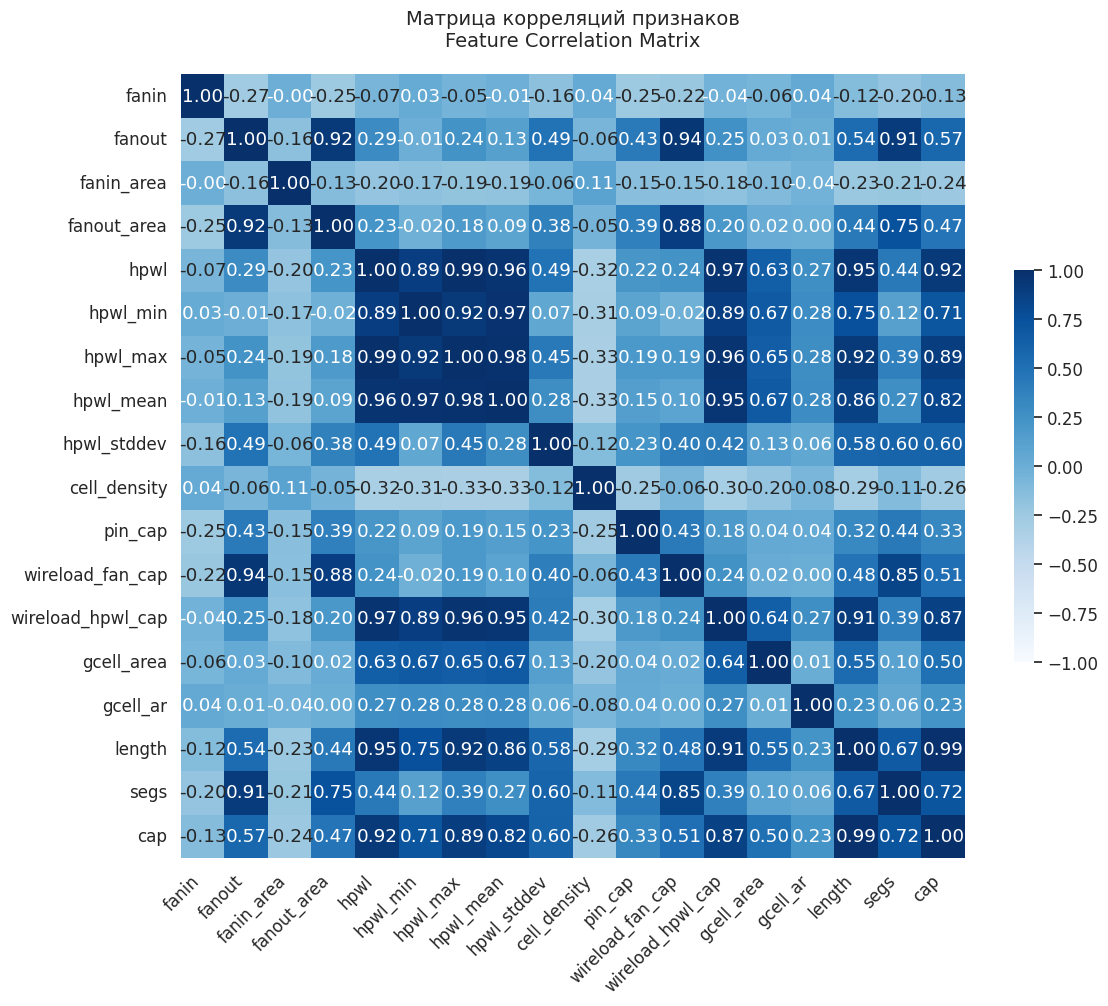

In [126]:
import matplotlib.pyplot as plt
import seaborn as sns

df_new = df[['fanin', 'fanout', 'fanin_area', 'fanout_area', 'hpwl', 'hpwl_min', 'hpwl_max', 'hpwl_mean', 'hpwl_stddev', 'cell_density', 'pin_cap', 'wireload_fan_cap', 'wireload_hpwl_cap','gcell_area', 'gcell_ar','length','segs','cap']]
#matrix = df_new.corr().round(3)

corr = df_new.corr()

styled_table = corr.style\
    .background_gradient(cmap='Blues', vmin=-1, vmax=1)\
    .format('{:.2f}', na_rep='')\
    .set_properties(**{
        'text-align': 'center',  # Центрирование по горизонтали
        'vertical-align': 'middle',  # Центрирование по вертикали
        'font-family': 'Arial',
        'font-size': '10pt'
    })\
    .set_table_styles([
        {'selector': 'th', 'props': [('text-align', 'center'), 
                                   ('vertical-align', 'middle'),
                                   ('font-weight', 'bold'),
                                   ('background-color', '#f0f0f0')]},
        {'selector': '', 'props': [('border', '1px solid black')]}
    ])

# Создаем heatmap с помощью matplotlib/seaborn
fig, ax = plt.subplots(figsize=(12, 10))

# Используем отфильтрованную матрицу, но для визуализации заменяем NaN на 0
corr_for_plot = corr.fillna(0)

sns.heatmap(corr_for_plot, 
            annot=True, 
            fmt='.2f', 
            cmap='Blues', 
            center=0,
            vmin=-1, vmax=1,
            square=True,
            cbar_kws={'shrink': 0.5},
            ax=ax)

plt.title('Матрица корреляций признаков\nFeature Correlation Matrix', fontsize=14, pad=20)
#plt.title('Feature Correlation Matrix', fontsize=14, pad=20)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)

# Сохраняем с высоким качеством для статьи
plt.tight_layout()
plt.savefig('correlation_matrix.png', dpi=300, bbox_inches='tight', 
            facecolor='white', edgecolor='none')
plt.show()


In [107]:
matrix.style.background_gradient(cmap='Blues', vmin=-1, vmax=1)

,fanin,fanout,fanin_area,fanout_area,hpwl,hpwl_min,hpwl_max,hpwl_mean,hpwl_stddev,cell_density,pin_cap,wireload_fan_cap,wireload_hpwl_cap,gcell_area,gcell_ar,length,segs,cap
fanin,1.000000,-0.271000,-0.004000,-0.248000,-0.068000,0.026000,-0.048000,-0.012000,-0.160000,0.037000,-0.247000,-0.220000,-0.038000,-0.062000,0.041000,-0.124000,-0.197000,-0.126000
fanout,-0.271000,1.000000,-0.157000,0.925000,0.292000,-0.006000,0.236000,0.127000,0.490000,-0.064000,0.432000,0.944000,0.255000,0.032000,0.009000,0.535000,0.913000,0.572000
fanin_area,-0.004000,-0.157000,1.000000,-0.125000,-0.197000,-0.171000,-0.192000,-0.187000,-0.062000,0.107000,-0.147000,-0.151000,-0.176000,-0.103000,-0.038000,-0.227000,-0.214000,-0.238000
fanout_area,-0.248000,0.925000,-0.125000,1.000000,0.226000,-0.016000,0.177000,0.089000,0.379000,-0.051000,0.387000,0.884000,0.197000,0.019000,0.004000,0.441000,0.749000,0.469000
hpwl,-0.068000,0.292000,-0.197000,0.226000,1.000000,0.888000,0.993000,0.963000,0.489000,-0.319000,0.216000,0.241000,0.968000,0.634000,0.269000,0.951000,0.445000,0.924000
hpwl_min,0.026000,-0.006000,-0.171000,-0.016000,0.888000,1.000000,0.919000,0.974000,0.067000,-0.312000,0.088000,-0.017000,0.890000,0.673000,0.284000,0.751000,0.119000,0.706000
hpwl_max,-0.048000,0.236000,-0.192000,0.177000,0.993000,0.919000,1.000000,0.982000,0.445000,-0.325000,0.192000,0.190000,0.964000,0.652000,0.276000,0.924000,0.389000,0.895000
hpwl_mean,-0.012000,0.127000,-0.187000,0.089000,0.963000,0.974000,0.982000,1.000000,0.278000,-0.325000,0.147000,0.097000,0.949000,0.675000,0.285000,0.861000,0.271000,0.824000
hpwl_stddev,-0.160000,0.490000,-0.062000,0.379000,0.489000,0.067000,0.445000,0.278000,1.000000,-0.117000,0.225000,0.404000,0.418000,0.134000,0.064000,0.584000,0.595000,0.603000
cell_density,0.037000,-0.064000,0.107000,-0.051000,-0.319000,-0.312000,-0.325000,-0.325000,-0.117000,1.000000,-0.254000,-0.065000,-0.301000,-0.200000,-0.078000,-0.292000,-0.113000,-0.264000


In [129]:
##DATA ANALYSIS
# Полный рабочий пример
def feature_selection_pipeline(df, target_col, corr_threshold=0.3):
    # Вычисляем корреляции
    correlations = df.corr()[target_col].drop(target_col)
    
    # Отбираем фичи по порогу
    selected_features = correlations[abs(correlations) > corr_threshold].index.tolist()
    
    print(f"Всего фич: {len(df.columns) - 1}")
    print(f"Отобрано фич: {len(selected_features)}")
    print(f"Лучшие фичи:")
    for feature in selected_features:
        print(f"  {feature}: {correlations[feature]:.3f}")

    print(selected_features)
    return selected_features

def select_features_with_multicollinearity(df, target_col, corr_threshold=0.1, multicoll_threshold=0.9):
    """
    Отбор фич с учетом мультиколлинеарности
    """
    corr_matrix = df.corr()
    target_corrs = corr_matrix[target_col].drop(target_col)
    
    # Отбираем фичи с достаточной корреляцией с целевой
    candidate_features = target_corrs[abs(target_corrs) > corr_threshold].index.tolist()
    
    # Проверяем мультиколлинеарность между фичами
    selected_features = []
    for feature in candidate_features:
        # Проверяем корреляцию с уже отобранными фичами
        high_corr_with_selected = False
        for selected in selected_features:
            if abs(corr_matrix.loc[feature, selected]) > multicoll_threshold:
                high_corr_with_selected = True
                break
        
        if not high_corr_with_selected:
            selected_features.append(feature)

    print("Лучшие фичи с учетом мульколинеарности")
    print(selected_features)

#capacitence
df.corr()['cap']

#feature selection
feature_selection_pipeline(df, 'cap')

#feature selection include multicolinear
select_features_with_multicollinearity(df, 'cap')

Всего фич: 29
Отобрано фич: 14
Лучшие фичи:
  fanout: 0.572
  fanout_area: 0.469
  hpwl: 0.924
  hpwl_min: 0.706
  hpwl_max: 0.895
  hpwl_mean: 0.824
  hpwl_stddev: 0.603
  pin_cap: 0.331
  wireload_fan_cap: 0.508
  wireload_hpwl_cap: 0.869
  length: 0.989
  segs: 0.718
  vias: 0.659
  gcell_area: 0.502
['fanout', 'fanout_area', 'hpwl', 'hpwl_min', 'hpwl_max', 'hpwl_mean', 'hpwl_stddev', 'pin_cap', 'wireload_fan_cap', 'wireload_hpwl_cap', 'length', 'segs', 'vias', 'gcell_area']
Лучшие фичи с учетом мульколинеарности
['fanin', 'fanout', 'fanin_area', 'hpwl', 'hpwl_min', 'hpwl_stddev', 'cell_density', 'pin_cap', 'gcell_area', 'gcell_ar']


In [28]:
def get_label_distibution(df, label):

    #get max, min, mean, std
    max = df[label].max()
    min = df [label].min()
    mean = df [label].mean()
    std = df [label].std()

    return max,min, mean, std

get_label_distibution(df, 'segs')

(np.int64(559),
 np.int64(1),
 np.float64(18.985974459105893),
 np.float64(33.691282437349884))

In [56]:
class BlockCrossValidation:
    def __init__(self, dataset_path='./dataset/', n_folds=7, random_state=42, 
                 feature_columns=None, target_columns=None):
        self.dataset_path = dataset_path
        self.n_folds = n_folds
        self.random_state = random_state
        
        # Колонки для фичей и таргетов
        self.feature_columns = feature_columns or [
            'fanin', 'fanout', 'fanin_area', 'fanout_area', 'hpwl'
        ]
        self.target_columns = target_columns or [
            'length', 'segs', 'vias', 'cap'
        ]
        
        self.blocks = self._get_blocks()
        self._validate_columns()
        
    def _validate_columns(self):
        """Проверить доступность колонок на примере первого блока"""
        if not self.blocks:
            return
            
        first_block = self.blocks[0]
        df = self._load_block_data(first_block)
        if df is not None:
            available_columns = set(df.columns)
            
            # Проверить фичи
            missing_features = set(self.feature_columns) - available_columns
            if missing_features:
                print(f"⚠️ Предупреждение: отсутствуют фичи: {missing_features}")
                print(f"Доступные колонки: {list(available_columns)}")
            
            # Проверить таргеты
            missing_targets = set(self.target_columns) - available_columns
            if missing_targets:
                print(f"⚠️ Предупреждение: отсутствуют таргеты: {missing_targets}")
    
    def _get_blocks(self):
        """Получить список всех блоков"""
        blocks = [d for d in os.listdir(self.dataset_path) 
                 if os.path.isdir(os.path.join(self.dataset_path, d))]
        print(f"Найдено блоков: {len(blocks)}")
        return sorted(blocks)
    
    def _load_block_data(self, block):
        """Загрузить данные для конкретного блока"""
        file_path = os.path.join(self.dataset_path, block, 'net_feat.csv')
        try:
            df = pd.read_csv(file_path, sep=';')
            
            #drop all nets with zero capacitence
            df = df[df['cap'] != 0]
            df = df[df['pin_cap'] != 0]

            #drop all Nan rows
            df = df.dropna()

            #drop net name clomun
            df = df.drop(columns=['net'], axis=1)

            #transfer capacintece from pF to fF
            df['cap'] = df['cap'] * 1000
            df['pin_cap'] = df['pin_cap'] * 1000
            df['wireload_fan_cap'] = df['wireload_fan_cap'] * 1000
            df['wireload_hpwl_cap'] = df['wireload_hpwl_cap'] * 1000

            #add block area feature
            df['block_area'] = df['block_width'] * df['block_height']

            #add area feature
            df['gcell_area'] = (df['urx'] - df['llx']) * (df['ury'] - df['lly'])

            #add aspect ration feat
            df['gcell_ar'] = (df['urx'] - df['llx']) / (df['ury'] - df['lly'])

            #ration wire cap / pin cap
            df ['wire_to_pin_cap_ratio'] = df['cap'] / df['pin_cap'] 
            
            return df
            
        except Exception as e:
            print(f"Ошибка загрузки блока {block}: {e}")
            return None
    
    def get_available_columns(self, block=None):
        """Получить список доступных колонок"""
        if block is None:
            block = self.blocks[0] if self.blocks else None
        
        if block:
            df = self._load_block_data(block)
            if df is not None:
                return list(df.columns)
        return []
    
    def set_feature_columns(self, feature_columns):
        """Установить новые фичи"""
        self.feature_columns = feature_columns
        self._validate_columns()
    
    def set_target_columns(self, target_columns):
        """Установить новые таргеты"""
        self.target_columns = target_columns
        self._validate_columns()
    
    def _prepare_folds(self):
        """Подготовить folds из блоков"""
        np.random.seed(self.random_state)
        blocks_shuffled = np.random.permutation(self.blocks)
        
        folds = []
        fold_size = len(blocks_shuffled) // self.n_folds
        
        for i in range(self.n_folds):
            start_idx = i * fold_size
            if i == self.n_folds - 1:
                # Последний fold берет все оставшиеся блоки
                test_blocks = blocks_shuffled[start_idx:]
            else:
                end_idx = (i + 1) * fold_size
                test_blocks = blocks_shuffled[start_idx:end_idx]
            
            train_blocks = [b for b in blocks_shuffled if b not in test_blocks]
            folds.append((train_blocks, test_blocks))
        
        return folds
    
    def get_cv_splits(self):
        """Генератор для получения train/test сплитов"""
        folds = self._prepare_folds()
        
        for fold_idx, (train_blocks, test_blocks) in enumerate(folds):
            print(f"\nFold {fold_idx + 1}/{self.n_folds}")
            print(f"Train blocks: {len(train_blocks)}, Test blocks: {len(test_blocks)}")
            print(f"Test blocks: {test_blocks}")
            
            # Загружаем и объединяем данные
            X_train, y_train = self._load_multiple_blocks(train_blocks)
            X_test, y_test = self._load_multiple_blocks(test_blocks)
            
            yield X_train, X_test, y_train, y_test, train_blocks, test_blocks
    
    def _load_multiple_blocks(self, blocks):
        """Загрузить и объединить данные из нескольких блоков"""
        X_list = []
        y_dict = {target: [] for target in self.target_columns}
        
        for block in blocks:
            df = self._load_block_data(block)
            if df is not None and not df.empty:
                try:
                    # Выбираем только нужные фичи
                    X = df[self.feature_columns].values
                    X_list.append(X)
                    
                    # Выбираем таргеты
                    for target in self.target_columns:
                        y_dict[target].extend(df[target].values)
                        
                except KeyError as e:
                    print(f"Ошибка в блоке {block}: отсутствует колонка {e}")
                    continue
        
        if not X_list:
            return np.array([]), {}
        
        X_combined = np.vstack(X_list)
        y_combined = {target: np.array(values) for target, values in y_dict.items()}
        
        return X_combined, y_combined

In [60]:
cv = BlockCrossValidation(
    dataset_path='./dataset/', 
        n_folds=7,
        feature_columns=['fanin', 'fanout', 'fanin_area', 'hpwl', 'hpwl_min', 'hpwl_stddev', 'cell_density', 'pin_cap', 'gcell_area', 'gcell_ar'],
        target_columns=['cap']
    )

Найдено блоков: 35


In [71]:
# Обновленные функции для работы с динамическими таргетами
def train_fold(model, train_loader, val_loader, optimizer, criterion, device, epochs=5):
    """Обучение для одного fold"""
    train_losses = []
    val_losses = []
    
    for epoch in range(epochs):
        # Training
        model.train()
        train_loss = 0
        for data, targets in train_loader:
            data = data.to(device)
            targets = {k: v.to(device) for k, v in targets.items()}
            
            optimizer.zero_grad()
            predictions = model(data)
            loss, _ = criterion(predictions, targets)
            loss.backward()
            optimizer.step()
            
            train_loss += loss.item()
        
        # Validation
        model.eval()
        val_loss = 0
        with torch.no_grad():
            for data, targets in val_loader:
                data = data.to(device)
                targets = {k: v.to(device) for k, v in targets.items()}
                predictions = model(data)
                loss, _ = criterion(predictions, targets)
                val_loss += loss.item()
        
        avg_train_loss = train_loss / len(train_loader)
        avg_val_loss = val_loss / len(val_loader)
        
        train_losses.append(avg_train_loss)
        val_losses.append(avg_val_loss)
        
        if epoch % 1 == 0:
            print(f'Epoch {epoch:3d} | Train Loss: {avg_train_loss:.4f} | Val Loss: {avg_val_loss:.4f}')
    
    return train_losses, val_losses

def evaluate_fold(model, test_loader, device, target_columns=None):
    """Оценка модели на тестовых данных"""
    model.eval()
    target_columns = target_columns or ['length', 'segs', 'vias', 'cap']
    
    predictions_dict = {task: [] for task in target_columns}
    targets_dict = {task: [] for task in target_columns}
    
    with torch.no_grad():
        for data, targets in test_loader:
            data = data.to(device)
            predictions = model(data)
            
            for task in target_columns:
                if task in predictions:
                    predictions_dict[task].extend(predictions[task].cpu().numpy())
                if task in targets:
                    targets_dict[task].extend(targets[task].cpu().numpy())
    
    # Расчет метрик
    metrics = {}
    for task in target_columns:
        if task in predictions_dict and len(predictions_dict[task]) > 0:
            y_true = np.array(targets_dict[task]).flatten()
            y_pred = np.array(predictions_dict[task]).flatten()
            
            non_zero_mask = y_true != 0
            y_true_non_zero = y_true[non_zero_mask]
            y_pred_non_zero = y_pred[non_zero_mask]
            
            has_non_zero = len(y_true_non_zero) > 0
            
            metrics[task] = {
                'mse': mean_squared_error(y_true, y_pred),
                'rmse': np.sqrt(mean_squared_error(y_true, y_pred)),
                'mae': mean_absolute_error(y_true, y_pred),
                'r2': r2_score(y_true, y_pred),
                'mape': mean_absolute_percentage_error(y_true_non_zero, y_pred_non_zero) if has_non_zero else None,
                'samples': len(y_true),
                'non_zero_samples': len(y_true_non_zero)
            }
    
    return metrics

def run_cross_validation(feature_columns=None, target_columns=None, n_folds=7, epochs=10):
    """Запуск кросс-валидации с кастомными фичами и таргетами"""
    # Инициализация
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    print(f"Используется устройство: {device}")
    
    cv = BlockCrossValidation(
        dataset_path='./dataset/', 
        n_folds=n_folds,
        feature_columns=feature_columns,
        target_columns=target_columns
    )
    
    # Показать доступные колонки
    available_columns = cv.get_available_columns()
    print(f"Доступные колонки: {available_columns}")
    print(f"Используемые фичи: {cv.feature_columns}")
    print(f"Используемые таргеты: {cv.target_columns}")
    
    # Для хранения результатов
    all_metrics = []
    fold_results = []
    
    # Cross Validation
    for fold_idx, (X_train, X_test, y_train, y_test, train_blocks, test_blocks) in enumerate(cv.get_cv_splits()):
        if len(X_train) == 0 or len(X_test) == 0:
            print(f"Пропускаем fold {fold_idx} - нет данных")
            continue
        
        print(f"\n=== Fold {fold_idx + 1} ===")
        print(f"Train samples: {len(X_train)}, Test samples: {len(X_test)}")
        print(f"Размерность фичей: {X_train.shape[1]}")
        
        # Масштабирование
        scaler = StandardScaler()
        X_train_scaled = scaler.fit_transform(X_train)
        X_test_scaled = scaler.transform(X_test)
        
        # Создание DataLoader с кастомным Dataset
        train_dataset = MultiTaskDataset(X_train_scaled, y_train)
        test_dataset = MultiTaskDataset(X_test_scaled, y_test)
        
        train_loader = DataLoader(train_dataset, batch_size=256, shuffle=True)
        test_loader = DataLoader(test_dataset, batch_size=256, shuffle=False)
        
        # Модель и оптимизатор
        params = {
        'objective': 'reg:squarederror',
        'n_estimators': 100,
        'max_depth': 20,
        'learning_rate': 0.1,
        #'subsample': 0.9,
        #'colsample_bytree': 0.9,
        #'gamma': 0.1,
        #'reg_alpha': 0.9,
        #'reg_lambda': 0.9
        }

        #create xgboost model
        model = xgb.XGBRegressor(**params)
        
        #criterion = MultiTaskLoss(target_columns=target_columns)
        #optimizer = torch.optim.Adam(model.parameters(), lr=0.0001, weight_decay=1e-5)
        
        # Обучение
        print("Обучение...")
        train_losses, val_losses = train_fold(
            model, train_loader, test_loader, optimizer, criterion, device, epochs=epochs
        )
        
        # Оценка
        print("Оценка...")
        metrics = evaluate_fold(model, test_loader, device, target_columns)
        
        # Сохраняем результаты
        fold_result = {
            'fold': fold_idx + 1,
            'train_blocks': train_blocks,
            'test_blocks': test_blocks,
            'train_samples': len(X_train),
            'test_samples': len(X_test),
            'feature_columns': cv.feature_columns,
            'target_columns': cv.target_columns,
            'metrics': metrics,
            'train_loss': train_losses[-1],
            'val_loss': val_losses[-1]
        }
        
        fold_results.append(fold_result)
        all_metrics.append(metrics)
        
        # Вывод результатов fold
        print(f"\nРезультаты Fold {fold_idx + 1}:")
        for task, task_metrics in metrics.items():
            print(f"  {task}: R²={task_metrics['r2']:.4f}, RMSE={task_metrics['rmse']:.4f}")
    
    return fold_results, all_metrics, cv.feature_columns, cv.target_columns

class MultiTaskDataset(Dataset):
    def __init__(self, X, y_dict):
        self.X = torch.FloatTensor(X)
        self.y_dict = {}
        for key, value in y_dict.items():
            self.y_dict[key] = torch.FloatTensor(value).unsqueeze(1)
    
    def __len__(self):
        return len(self.X)
    
    def __getitem__(self, idx):
        return self.X[idx], {key: value[idx] for key, value in self.y_dict.items()}

class MultiTaskLoss(nn.Module):
    def __init__(self, weights=None, target_columns=None):
        super(MultiTaskLoss, self).__init__()
        self.target_columns = target_columns or ['length', 'segs', 'vias', 'cap']
        default_weights = {
            'length': 0.3, 'segs': 0.2, 'vias': 0.2, 'cap': 1.0
        }
        # Оставляем только веса для существующих таргетов
        self.weights = {k: v for k, v in (weights or default_weights).items() 
                       if k in self.target_columns}
        self.mse_loss = nn.MSELoss()
    
    def forward(self, predictions, targets):
        losses = {}
        for task in self.target_columns:
            if task in predictions and task in targets:
                losses[task] = self.mse_loss(predictions[task], targets[task])
        
        total_loss = sum(self.weights.get(task, 1.0) * loss 
                        for task, loss in losses.items())
        return total_loss, losses

In [72]:
run_cross_validation(feature_columns=['fanin', 'fanout', 'fanin_area', 'hpwl', 'hpwl_min', 'hpwl_stddev', 'cell_density', 'pin_cap', 'gcell_area', 'gcell_ar'], target_columns=['cap'], n_folds=7, epochs=10)

Используется устройство: cuda
Найдено блоков: 35
Доступные колонки: ['block_width', 'block_height', 'fanin', 'fanout', 'fanin_area', 'fanout_area', 'llx', 'lly', 'urx', 'ury', 'hpwl', 'hpwl_min', 'hpwl_max', 'hpwl_mean', 'hpwl_stddev', 'cell_density', 'pin_cap', 'wireload_fan_cap', 'wireload_hpwl_cap', 'm2_segs', 'm3_segs', 'm4_segs', 'm5_segs', 'm6_segs', 'm7_segs', 'length', 'segs', 'vias', 'cap', 'block_area', 'gcell_area', 'gcell_ar', 'wire_to_pin_cap_ratio']
Используемые фичи: ['fanin', 'fanout', 'fanin_area', 'hpwl', 'hpwl_min', 'hpwl_stddev', 'cell_density', 'pin_cap', 'gcell_area', 'gcell_ar']
Используемые таргеты: ['cap']

Fold 1/7
Train blocks: 30, Test blocks: 5
Test blocks: ['sasc_top' 'dynamic_node_top_wrap' 'risc16f84_clk2x' 'picosoc'
 'jpeg_encoder']

=== Fold 1 ===
Train samples: 514566, Test samples: 50332
Размерность фичей: 10
Обучение...


NameError: name 'optimizer' is not defined

In [75]:
import xgboost as xgb
from sklearn.multioutput import MultiOutputRegressor
import numpy as np
import pandas as pd
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.preprocessing import StandardScaler
import os

# Обновленные функции для работы с XGBoost
def train_fold_xgb(model, X_train, y_train, X_val, y_val, target_columns, epochs=100):
    """Обучение XGBoost для одного fold"""
    train_losses = []
    val_losses = []
    
    for task in target_columns:
        print(f"Обучение для задачи: {task}")
        
        # Обучаем для каждой целевой переменной отдельно
        model.fit(
            X_train, y_train[task],
            eval_set=[(X_val, y_val[task])],
            verbose=False
        )
        
        # Предсказания и метрики
        y_pred_train = model.predict(X_train)
        y_pred_val = model.predict(X_val)
        
        train_loss = mean_squared_error(y_train[task], y_pred_train)
        val_loss = mean_squared_error(y_val[task], y_pred_val)
        
        train_losses.append(train_loss)
        val_losses.append(val_loss)
        
        print(f"  {task}: Train Loss: {train_loss:.4f}, Val Loss: {val_loss:.4f}")
    
    return train_losses, val_losses

def evaluate_fold_xgb(model, X_test, y_test, target_columns):
    """Оценка XGBoost модели на тестовых данных"""
    metrics = {}
    
    for task in target_columns:
        y_true = y_test[task]
        y_pred = model.predict(X_test)
        
        non_zero_mask = y_true != 0
        y_true_non_zero = y_true[non_zero_mask]
        y_pred_non_zero = y_pred[non_zero_mask]
        
        has_non_zero = len(y_true_non_zero) > 0
        
        metrics[task] = {
            'mse': mean_squared_error(y_true, y_pred),
            'rmse': np.sqrt(mean_squared_error(y_true, y_pred)),
            'mae': mean_absolute_error(y_true, y_pred),
            'r2': r2_score(y_true, y_pred),
            'mape': mean_absolute_percentage_error(y_true_non_zero, y_pred_non_zero) if has_non_zero else None,
            'samples': len(y_true),
            'non_zero_samples': len(y_true_non_zero)
        }
    
    return metrics

def mean_absolute_percentage_error(y_true, y_pred):
    """Безопасный расчет MAPE"""
    if len(y_true) == 0:
        return None
    return np.mean(np.abs((y_true - y_pred) / y_true)) * 100

class BlockCrossValidation:
    def __init__(self, dataset_path='./dataset/', n_folds=7, random_state=42, 
                 feature_columns=None, target_columns=None):
        self.dataset_path = dataset_path
        self.n_folds = n_folds
        self.random_state = random_state
        
        # Колонки для фичей и таргетов
        self.feature_columns = feature_columns or [
            'fanin', 'fanout', 'fanin_area', 'fanout_area', 'hpwl'
        ]
        self.target_columns = target_columns or [
            'length', 'segs', 'vias', 'cap'
        ]
        
        self.blocks = self._get_blocks()
        
    def _get_blocks(self):
        """Получить список всех блоков"""
        blocks = [d for d in os.listdir(self.dataset_path) 
                 if os.path.isdir(os.path.join(self.dataset_path, d))]
        print(f"Найдено блоков: {len(blocks)}")
        return sorted(blocks)
    
    def _load_block_data(self, block):
        """Загрузить данные для конкретного блока"""
        file_path = os.path.join(self.dataset_path, block, 'net_feat.csv')
        try:
            df = pd.read_csv(file_path, sep=';')
            return df
        except Exception as e:
            print(f"Ошибка загрузки блока {block}: {e}")
            return None
    
    def get_available_columns(self, block=None):
        """Получить список доступных колонок"""
        if block is None:
            block = self.blocks[0] if self.blocks else None
        
        if block:
            df = self._load_block_data(block)
            if df is not None:
                return list(df.columns)
        return []
    
    def _prepare_folds(self):
        """Подготовить folds из блоков"""
        np.random.seed(self.random_state)
        blocks_shuffled = np.random.permutation(self.blocks)
        
        folds = []
        fold_size = len(blocks_shuffled) // self.n_folds
        
        for i in range(self.n_folds):
            start_idx = i * fold_size
            if i == self.n_folds - 1:
                test_blocks = blocks_shuffled[start_idx:]
            else:
                end_idx = (i + 1) * fold_size
                test_blocks = blocks_shuffled[start_idx:end_idx]
            
            train_blocks = [b for b in blocks_shuffled if b not in test_blocks]
            folds.append((train_blocks, test_blocks))
        
        return folds
    
    def get_cv_splits(self):
        """Генератор для получения train/test сплитов"""
        folds = self._prepare_folds()
        
        for fold_idx, (train_blocks, test_blocks) in enumerate(folds):
            print(f"\nFold {fold_idx + 1}/{self.n_folds}")
            print(f"Train blocks: {len(train_blocks)}, Test blocks: {len(test_blocks)}")
            print(f"Test blocks: {test_blocks}")
            
            # Загружаем и объединяем данные
            X_train, y_train = self._load_multiple_blocks(train_blocks)
            X_test, y_test = self._load_multiple_blocks(test_blocks)
            
            yield X_train, X_test, y_train, y_test, train_blocks, test_blocks
    
    def _load_multiple_blocks(self, blocks):
        """Загрузить и объединить данные из нескольких блоков"""
        X_list = []
        y_dict = {target: [] for target in self.target_columns}
        
        for block in blocks:
            df = self._load_block_data(block)
            if df is not None and not df.empty:
                try:
                    # Выбираем только нужные фичи
                    X = df[self.feature_columns].values
                    X_list.append(X)
                    
                    # Выбираем таргеты
                    for target in self.target_columns:
                        if target in df.columns:
                            y_dict[target].extend(df[target].values)
                        else:
                            print(f"Предупреждение: колонка {target} не найдена в блоке {block}")
                            y_dict[target].extend([0] * len(df))
                            
                except KeyError as e:
                    print(f"Ошибка в блоке {block}: отсутствует колонка {e}")
                    continue
        
        if not X_list:
            return np.array([]), {}
        
        X_combined = np.vstack(X_list)
        y_combined = {target: np.array(values) for target, values in y_dict.items()}
        
        print(f"Загружено {X_combined.shape[0]} samples, {X_combined.shape[1]} features")
        
        return X_combined, y_combined

def run_cross_validation_xgb(feature_columns=None, target_columns=None, n_folds=7, epochs=100):
    """Запуск кросс-валидации с XGBoost"""
    # Инициализация
    cv = BlockCrossValidation(
        dataset_path='./dataset/', 
        n_folds=n_folds,
        feature_columns=feature_columns,
        target_columns=target_columns
    )
    
    # Показать доступные колонки
    available_columns = cv.get_available_columns()
    print(f"Доступные колонки: {available_columns}")
    print(f"Используемые фичи: {cv.feature_columns}")
    print(f"Используемые таргеты: {cv.target_columns}")
    
    # Для хранения результатов
    all_metrics = []
    fold_results = []
    
    # Cross Validation
    for fold_idx, (X_train, X_test, y_train, y_test, train_blocks, test_blocks) in enumerate(cv.get_cv_splits()):
        if len(X_train) == 0 or len(X_test) == 0:
            print(f"Пропускаем fold {fold_idx} - нет данных")
            continue
        
        print(f"\n=== Fold {fold_idx + 1} ===")
        print(f"Train samples: {len(X_train)}, Test samples: {len(X_test)}")
        print(f"Размерность фичей: {X_train.shape[1]}")
        
        # Масштабирование
        scaler = StandardScaler()
        X_train_scaled = scaler.fit_transform(X_train)
        X_test_scaled = scaler.transform(X_test)
        
        # Параметры XGBoost
        params = {
            'objective': 'reg:squarederror',
            'n_estimators': epochs,
            'max_depth': 20,
            'learning_rate': 0.1,
            'random_state': 42
        }
        
        # Обучаем отдельную модель для каждой целевой переменной
        models = {}
        fold_metrics = {}
        
        for task in target_columns:
            print(f"Обучение XGBoost для: {task}")
            
            # Создаем модель для текущей задачи
            model = xgb.XGBRegressor(**params)
            
            # Обучение
            model.fit(
                X_train_scaled, y_train[task],
                eval_set=[(X_test_scaled, y_test[task])],
                verbose=False
            )
            
            models[task] = model
            
            # Оценка
            y_pred = model.predict(X_test_scaled)
            
            # Расчет метрик
            y_true = y_test[task]
            non_zero_mask = y_true != 0
            y_true_non_zero = y_true[non_zero_mask]
            y_pred_non_zero = y_pred[non_zero_mask]
            
            has_non_zero = len(y_true_non_zero) > 0
            
            fold_metrics[task] = {
                'mse': mean_squared_error(y_true, y_pred),
                'rmse': np.sqrt(mean_squared_error(y_true, y_pred)),
                'mae': mean_absolute_error(y_true, y_pred),
                'r2': r2_score(y_true, y_pred),
                'mape': mean_absolute_percentage_error(y_true_non_zero, y_pred_non_zero) if has_non_zero else None,
                'samples': len(y_true),
                'non_zero_samples': len(y_true_non_zero)
            }
            
            print(f"  {task}: R²={fold_metrics[task]['r2']:.4f}, RMSE={fold_metrics[task]['rmse']:.4f}")
        
        # Сохраняем результаты
        fold_result = {
            'fold': fold_idx + 1,
            'train_blocks': train_blocks,
            'test_blocks': test_blocks,
            'train_samples': len(X_train),
            'test_samples': len(X_test),
            'feature_columns': cv.feature_columns,
            'target_columns': cv.target_columns,
            'metrics': fold_metrics,
            'models': models
        }
        
        fold_results.append(fold_result)
        all_metrics.append(fold_metrics)
        
        # Вывод результатов fold
        print(f"\nРезультаты Fold {fold_idx + 1}:")
        for task, task_metrics in fold_metrics.items():
            print(f"  {task}: R²={task_metrics['r2']:.4f}, RMSE={task_metrics['rmse']:.4f}")
    
    # Сводка по всем folds
    print_cv_summary_xgb(fold_results)
    
    return fold_results, all_metrics, cv.feature_columns, cv.target_columns

def print_cv_summary_xgb(fold_results):
    """Печать суммарных результатов CV для XGBoost"""
    print("\n" + "="*80)
    print("СВОДКА КРОСС-ВАЛИДАЦИИ XGBoost")
    print("="*80)
    
    if not fold_results:
        print("Нет результатов для анализа")
        return
    
    tasks = list(fold_results[0]['metrics'].keys())
    
    for task in tasks:
        print(f"\n📊 {task.upper()} - Средние метрики по всем folds:")
        
        r2_scores = [result['metrics'][task]['r2'] for result in fold_results]
        rmse_scores = [result['metrics'][task]['rmse'] for result in fold_results]
        mae_scores = [result['metrics'][task]['mae'] for result in fold_results]
        
        print(f"  R²:    {np.mean(r2_scores):.4f} ± {np.std(r2_scores):.4f}")
        print(f"  RMSE:  {np.mean(rmse_scores):.4f} ± {np.std(rmse_scores):.4f}")
        print(f"  MAE:   {np.mean(mae_scores):.4f} ± {np.std(mae_scores):.4f}")
        
        # Детали по folds
        print(f"  R² по folds: {[f'{x:.4f}' for x in r2_scores]}")
    
    # Общая статистика
    print(f"\n📈 Общая статистика:")
    total_train_samples = sum([result['train_samples'] for result in fold_results])
    total_test_samples = sum([result['test_samples'] for result in fold_results])
    print(f"  Всего train samples: {total_train_samples}")
    print(f"  Всего test samples: {total_test_samples}")

# Альтернативная версия с MultiOutputRegressor (если хотите одну модель для всех таргетов)
def run_cross_validation_xgb_multioutput(feature_columns=None, target_columns=None, n_folds=7, epochs=100):
    """Запуск кросс-валидации с MultiOutput XGBoost"""
    cv = BlockCrossValidation(
        dataset_path='./dataset/', 
        n_folds=n_folds,
        feature_columns=feature_columns,
        target_columns=target_columns
    )
    
    all_metrics = []
    fold_results = []
    
    for fold_idx, (X_train, X_test, y_train, y_test, train_blocks, test_blocks) in enumerate(cv.get_cv_splits()):
        if len(X_train) == 0 or len(X_test) == 0:
            print(f"Пропускаем fold {fold_idx} - нет данных")
            continue
        
        print(f"\n=== Fold {fold_idx + 1} ===")
        
        # Масштабирование
        scaler = StandardScaler()
        X_train_scaled = scaler.fit_transform(X_train)
        X_test_scaled = scaler.transform(X_test)
        
        # Подготовка таргетов для MultiOutput
        y_train_multi = np.column_stack([y_train[task] for task in target_columns])
        y_test_multi = np.column_stack([y_test[task] for task in target_columns])
        
        # Параметры XGBoost
        params = {
            'objective': 'reg:squarederror',
            'n_estimators': epochs,
            'max_depth': 20,
            'learning_rate': 0.1,
            'random_state': 42
        }
        
        # MultiOutput модель
        print("Обучение MultiOutput XGBoost...")
        model = MultiOutputRegressor(xgb.XGBRegressor(**params))
        model.fit(X_train_scaled, y_train_multi)
        
        # Предсказания
        y_pred_multi = model.predict(X_test_scaled)
        
        # Расчет метрик для каждой задачи
        fold_metrics = {}
        for i, task in enumerate(target_columns):
            y_true = y_test[task]
            y_pred = y_pred_multi[:, i]
            
            non_zero_mask = y_true != 0
            y_true_non_zero = y_true[non_zero_mask]
            y_pred_non_zero = y_pred[non_zero_mask]
            
            has_non_zero = len(y_true_non_zero) > 0
            
            fold_metrics[task] = {
                'mse': mean_squared_error(y_true, y_pred),
                'rmse': np.sqrt(mean_squared_error(y_true, y_pred)),
                'mae': mean_absolute_error(y_true, y_pred),
                'r2': r2_score(y_true, y_pred),
                'mape': mean_absolute_percentage_error(y_true_non_zero, y_pred_non_zero) if has_non_zero else None,
                'samples': len(y_true),
                'non_zero_samples': len(y_true_non_zero)
            }
        
        # Сохраняем результаты
        fold_result = {
            'fold': fold_idx + 1,
            'train_blocks': train_blocks,
            'test_blocks': test_blocks,
            'train_samples': len(X_train),
            'test_samples': len(X_test),
            'metrics': fold_metrics,
            'model': model
        }
        
        fold_results.append(fold_result)
        all_metrics.append(fold_metrics)
        
        # Вывод результатов
        print(f"Результаты Fold {fold_idx + 1}:")
        for task, task_metrics in fold_metrics.items():
            print(f"  {task}: R²={task_metrics['r2']:.4f}, RMSE={task_metrics['rmse']:.4f}")
    
    print_cv_summary_xgb(fold_results)
    return fold_results, all_metrics, cv.feature_columns, cv.target_columns

# Запуск кросс-валидации с XGBoost
if __name__ == "__main__":
    # Ваши фичи и таргеты
    features = ['fanin', 'fanout', 'fanin_area', 'fanout_area', 'hpwl']
    targets = ['length', 'segs', 'vias', 'cap']
    
    print("🚀 Запуск кросс-валидации с XGBoost")
    
    # Версия 1: Отдельные модели для каждого таргета (рекомендуется)
    fold_results, all_metrics, used_features, used_targets = run_cross_validation_xgb(
        feature_columns=features,
        target_columns=targets,
        n_folds=7,  # Начните с малого количества folds
        epochs=100
    )
    
    # Версия 2: MultiOutput модель (альтернатива)
    # fold_results, all_metrics, used_features, used_targets = run_cross_validation_xgb_multioutput(
    #     feature_columns=features,
    #     target_columns=targets,
    #     n_folds=3,
    #     epochs=100
    # )

🚀 Запуск кросс-валидации с XGBoost
Найдено блоков: 35
Доступные колонки: ['net', 'block_width', 'block_height', 'fanin', 'fanout', 'fanin_area', 'fanout_area', 'llx', 'lly', 'urx', 'ury', 'hpwl', 'hpwl_min', 'hpwl_max', 'hpwl_mean', 'hpwl_stddev', 'cell_density', 'pin_cap', 'wireload_fan_cap', 'wireload_hpwl_cap', 'm2_segs', 'm3_segs', 'm4_segs', 'm5_segs', 'm6_segs', 'm7_segs', 'length', 'segs', 'vias', 'cap']
Используемые фичи: ['fanin', 'fanout', 'fanin_area', 'fanout_area', 'hpwl']
Используемые таргеты: ['length', 'segs', 'vias', 'cap']

Fold 1/7
Train blocks: 30, Test blocks: 5
Test blocks: ['sasc_top' 'dynamic_node_top_wrap' 'risc16f84_clk2x' 'picosoc'
 'jpeg_encoder']
Загружено 733869 samples, 5 features
Загружено 74160 samples, 5 features

=== Fold 1 ===
Train samples: 733869, Test samples: 74160
Размерность фичей: 5
Обучение XGBoost для: length


XGBoostError: [20:24:28] /workspace/src/data/array_interface.cu:44: Check failed: err == cudaGetLastError() (0 vs. 46) : 
Stack trace:
  [bt] (0) /home/nzheludkov/phd/env/lib/python3.12/site-packages/xgboost/lib/libxgboost.so(+0x2a6ecc) [0x7f73c0ca6ecc]
  [bt] (1) /home/nzheludkov/phd/env/lib/python3.12/site-packages/xgboost/lib/libxgboost.so(+0xb862dc) [0x7f73c15862dc]
  [bt] (2) /home/nzheludkov/phd/env/lib/python3.12/site-packages/xgboost/lib/libxgboost.so(+0x565ece) [0x7f73c0f65ece]
  [bt] (3) /home/nzheludkov/phd/env/lib/python3.12/site-packages/xgboost/lib/libxgboost.so(XGDMatrixSetInfoFromInterface+0x10b) [0x7f73c0bb3e5b]
  [bt] (4) /lib/x86_64-linux-gnu/libffi.so.8(+0x7b16) [0x7f7539113b16]
  [bt] (5) /lib/x86_64-linux-gnu/libffi.so.8(+0x43ef) [0x7f75391103ef]
  [bt] (6) /lib/x86_64-linux-gnu/libffi.so.8(ffi_call+0x12e) [0x7f75391130be]
  [bt] (7) /usr/lib/python3.12/lib-dynload/_ctypes.cpython-312-x86_64-linux-gnu.so(+0xe11c) [0x7f75393c011c]
  [bt] (8) /usr/lib/python3.12/lib

In [180]:
y_pred = df['wireload_hpwl_cap']
y_real = df['cap']

mae = mean_absolute_error(y_pred, y_real)
mape = mean_absolute_percentage_error(y_pred, y_real)
r2 = r2_score(y_pred, y_real)

print(mae, mape, r2)

196.58983558801768 0.9753095510345134 -0.14168854865394764


In [165]:
mae = [97]
mape = [97]
r2 = [-0.28]

In [169]:
mean = sum(r2) / len(r2)
mean

0.22571428571428573

In [174]:
import statistics

#numbers = [10, 20, 30, 40, 50]
mean_value = statistics.stdev(r2)
print(f"The mean is: {mean_value}")

The mean is: 0.1530639455540443
